Import libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import math

Download BBCA data

In [2]:
df = yf.download("BBCA", start="2015-01-01", end="2026-01-01")

df = df[['Close']]
df.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


Log return

In [3]:
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

Feature Engineering Entropy

In [4]:
def entropy(series, bins=10):
    hist, _ = np.histogram(series, bins=bins, density=False)
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log(prob))

window = 30

entropy_values = []
for i in range(len(df)):
    if i < window:
        entropy_values.append(np.nan)
    else:
        ent = entropy(df['Return'].iloc[i-window:i])
        entropy_values.append(ent)

df['Entropy'] = entropy_values
df.dropna(inplace=True)

SPLIT AND Normalize

In [5]:
features = df[['Close', 'Return', 'Entropy']].values

n = len(features)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = features[:train_end]
val_data = features[train_end:val_end]
test_data = features[val_end:]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [6]:
# --- PARAMETERS ---
time_steps = 30

# --- SCALING ---
scaled_all = scaler.transform(features)

# --- SEQUENCE FUNCTION ---
def create_sequences(full_data, start, end, time_steps):
    X, y = [], []
    for i in range(start, end):
        if i < time_steps:
            continue
        X.append(full_data[i-time_steps:i])
        y.append(full_data[i, 0])
    return np.array(X), np.array(y)

# --- DATA SPLIT ---
X_train, y_train = create_sequences(scaled_all, time_steps, train_end, time_steps)
X_val, y_val = create_sequences(scaled_all, train_end, val_end, time_steps)
X_test, y_test = create_sequences(scaled_all, val_end, n, time_steps)

LSTM MODEL

In [7]:
model = Sequential([
    LSTM(128, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adamW', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop]
)

c:\Users\Satri\Downloads\dataset gambar\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0233 - val_loss: 0.0020
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 8.3649e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.7458e-04 - val_loss: 0.0011
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 9.0929e-04 - val_loss: 6.5583e-04
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.4624e-04 - val_loss: 0.0019
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.2766e-04 - val_loss: 0.0011
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.2218e-04 - val_loss: 6.0562e-04
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.9132e-04 - val_loss: 5.7968e-04
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.0734e-04 - val_loss: 6.9476e-04
Epoc

EVALUATION

In [8]:
train_pred = model.predict(X_train)
val_pred   = model.predict(X_val)
test_pred  = model.predict(X_test)

def inverse_transform(pred, X):
    temp = np.zeros((len(pred), X.shape[2]))
    temp[:, 0] = pred[:, 0]
    return scaler.inverse_transform(temp)[:, 0]

train_pred_actual = inverse_transform(train_pred, X_train)
val_pred_actual   = inverse_transform(val_pred, X_val)
test_pred_actual  = inverse_transform(test_pred, X_test)

y_train_actual = inverse_transform(y_train.reshape(-1,1), X_train)
y_val_actual   = inverse_transform(y_val.reshape(-1,1), X_val)
y_test_actual  = inverse_transform(y_test.reshape(-1,1), X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [9]:
mean_squared_error(y_train_actual, train_pred_actual)

1.0217782672933697

In [10]:
mean_squared_error(y_val_actual, val_pred_actual)

0.738517098710637

In [11]:
mse = mean_squared_error(y_test_actual, test_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_pred_actual)
r2 = r2_score(y_test_actual, test_pred_actual)

print("TEST RESULTS:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

TEST RESULTS:
MSE: 1.9999728048509282
RMSE: 1.414203947403248
MAE: 1.1021349879916191
R2: 0.9641473273652049


PLOT PREDICTED VS ACTUAL

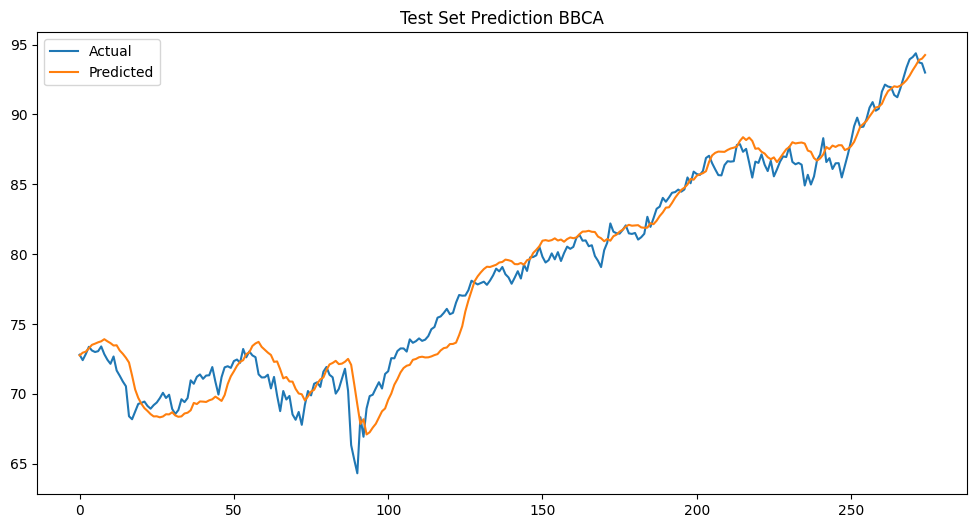

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(test_pred_actual, label='Predicted')
plt.legend()
plt.title("Test Set Prediction BBCA")
plt.show()